# Lab 10: Pharmacogenomic Analysis - Drug Sensitivity in Breast Cancer

## Overview  
This analysis explores the inhibitory efficiency (IC50) of a drug in breast cancer using the **Genomics of Drug Sensitivity in Cancer (GDSC)** dataset. We compare various experiments by analyzing key biological and experimental features that influence drug response.

**Recall** that the IC50 represents the drug concentration needed to inhibit 50% of cell viability in cell line experiments.
<img src="dose-response-curve.png" alt="drawing" style="width:500px;"/>

## Topics Covered

### 1. Data Processing / Exploration
In this step, we will load the GDSC dataset and perform initial data processing and exploration. This includes:
- Loading the dataset and displaying summary statistics.
- Visualizing the distribution of key variables, such as the IC50 values, to understand the data better.

### 2. Framing the Question / Formatting the Data for ML
In this step, we will frame the machine learning question we want to answer. This includes:
- Defining the target variable (e.g., binary classification of drug sensitivity based on IC50 values) and the features (e.g., gene expression levels, mutation status).
- Splitting the data into training and testing sets to evaluate the performance of our models.

### 3. Implementing ML Models
In this step, we will implement and evaluate various machine learning models to predict drug sensitivity. This includes:
- Building a simple baseline model, such as logistic regression, to establish a performance benchmark.
- Implementing more advanced models, such as decision trees, random forests, or support vector machines, to improve prediction accuracy.
- Evaluating the performance of the models using appropriate metrics, such as or accuracy, F1-score, etc.
- Visualizing the results to interpret the model's performance and understand the key features influencing drug sensitivity.


## 1. Data Processing / Exploration

We will start by loading a semi-curated dataset, where the raw data is available from the Genomics of Drug Sensitivity in Cancer (GDSC) database (https://www.cancerrxgene.org/).

In [1]:
# Package imports - loading and plotting stuff
import pandas as pd, numpy as np, random
import matplotlib.pyplot as plt, seaborn as sns

# Load / quick formatting
raw_data = pd.read_csv("GDSC_DATASET.csv")  
raw_data.columns = [" ".join(x.split("\n")).lower() for x in raw_data.columns]

**Columns of GDSC dataset:**
1. **COSMIC_ID:** Unique identifier for the cell line from the COSMIC database.
2. **CELL_LINE_NAME:** Name of the cancer cell line used in the experiment.
3. **TCGA_DESC:** Description of the cancer type according to The Cancer Genome Atlas.
4. **DRUG_ID:** Unique identifier for the drug used in the experiment.
5. **DRUG_NAME:** Name of the drug used in the experiment.
6. **LN_IC50:** Natural log of the half-maximal inhibitory concentration (IC50).
7. **AUC:** Area Under the Curve, a measure of drug effectiveness.
9. **Z_SCORE:** Standardized score of the drug response, allowing comparison across different drugs and cell lines.
9. **GDSC Tissue descriptor 1:** Primary tissue type classification.
10. **GDSC Tissue descriptor 2:** Secondary tissue type classification.
11. **Cancer Type (matching TCGA label):** Cancer type according to TCGA classification.
12. **Microsatellite instability Status (MSI):** Indicates the cell line's MSI status.
13. **Screen Medium:** The growth medium used for culturing the cell line.
14. **Growth Properties:** Characteristics of how the cell line grows in culture.
15. **Copy Number Alterations (CNA):** Data on gene copy number changes in the cell line.
16. **Gene Expression:** Information on gene expression levels in the cell line.
17. **Methylation:** Data on DNA methylation patterns in the cell line.
18. **TARGET:** The molecular target(s) of the drug.
19. **TARGET_PATHWAY:** The biological pathway(s) targeted by the drug.

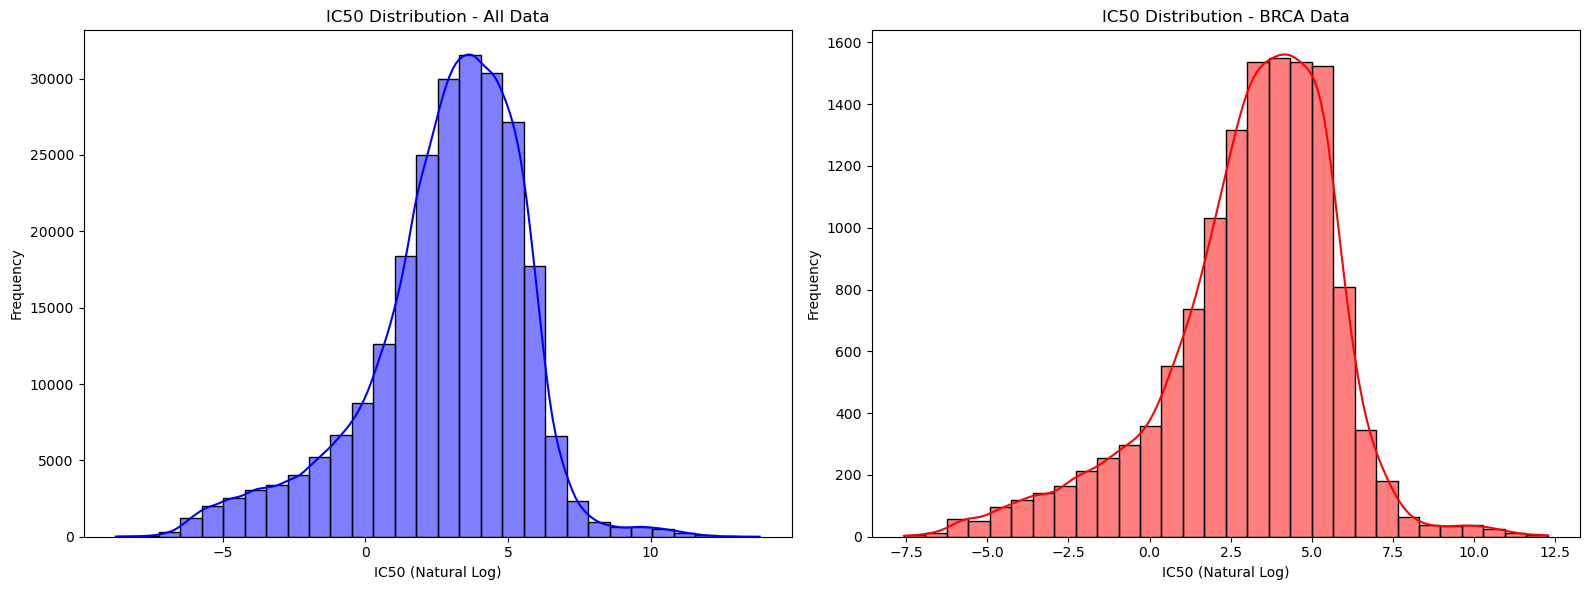

In [2]:
# Isolate the breast cancer data
brca_data = raw_data.copy()[raw_data["tcga_desc"] == "BRCA"]

# Visualize the IC50 Distribution for all data and our subset of interest
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(raw_data["ln_ic50"], bins=30, kde=True, color='blue', ax=axes[0])
axes[0].set_title('IC50 Distribution - All Data')
axes[0].set_xlabel("IC50 (Natural Log)")
axes[0].set_ylabel("Frequency")

sns.histplot(brca_data["ln_ic50"], bins=30, kde=True, color='red', ax=axes[1])
axes[1].set_title('IC50 Distribution - BRCA Data')
axes[1].set_xlabel("IC50 (Natural Log)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [3]:
raw_data.tcga_desc.value_counts()
# drop any rows with missing values in the columns we care about
print("Before dropping missing values:", brca_data.shape)
brca_data = brca_data.dropna(subset=["ln_ic50", "microsatellite instability status (msi)", "growth properties"])
print("After dropping missing values:", brca_data.shape)

Before dropping missing values: (13106, 19)
After dropping missing values: (12823, 19)


## Questions for Exploration

1. How many experiments are in this dataset (i.e., number of rows)?
2. How many different cancer types are represented? Which are the top 3 in terms of number of experiments available?
3. What are the correlations between numerical features and the target variable (IC50)? Is this expected?
4. What is the distribution of IC50 values across different categories (e.g., MSI status, screen medium)?

## 2. Framing the Question / Formatting the Data for ML
In this step, we will frame the machine learning question we want to answer. 

### Pairwise Comparison Approach  
- Each experiment is represented as a feature vector $X_a$ and $X_b$.  
- We compare the IC50 values ($y_a$, $y_b$) between two experiments to determine which experimental condition leads to higher or lower drug sensitivity.  
- This transforms the problem into a binary classification task, where the model predicts whether one condition results in an increase or decrease in IC50. 

### Features Considered  
- **Binary Features:**  
  - Microsatellite instability (MSI) status  
  - Screen medium  
  - Copy number alterations (CNA)  
  - Gene expression  
  - Methylation  

- **Ternary Feature:**  
  - Growth properties of cancer cells (adherent, semi-adherent, suspension)  

- **Drug Target Pathway:**  
  - Captures the molecular mechanism of action of the drug   

In [4]:
# data clean-up / curation

# Isolate the data of interest
cols_to_keep = ["microsatellite instability status (msi)", "screen medium", "cna", "gene expression", "methylation", "growth properties", "target_pathway"]              
y = brca_data.copy()["ln_ic50"] # target variable
X = brca_data.copy()[cols_to_keep] 

# Encode categorical features
X["microsatellite instability status (msi)"] = X["microsatellite instability status (msi)"].map({"MSS/MSI-L": 1, "MSI-H": 0})
X["growth properties"] = X["growth properties"].map({"Adherent": 0, "Semi-adherent": 1, "Suspension": 2})
X["screen medium"] = X["screen medium"].map({"D/F12": 0, "R": 1})
X["cna"] = X["cna"].map({"Y": 1, "N": 0})
X["gene expression"] = X["gene expression"].map({"Y": 1, "N": 0})
X["methylation"] = X["methylation"].map({"Y": 1, "N": 0})

# Encode drug target pathway
X = pd.get_dummies(X, columns=["target_pathway"])
# X.head()

In [5]:
from sklearn.model_selection import train_test_split

# Generate pairwise indices for training and testing sets
def generate_pairwise_indices(X, y, n_pairs=80_000):
    idx = np.array([(a, b) for a, b in zip(random.choices(X.index, k=n_pairs), random.choices(X.index, k=n_pairs)) if a != b])
    X_diff = X.loc[idx[:, 0]].to_numpy() - X.loc[idx[:, 1]].to_numpy()
    y_diff = y.loc[idx[:, 0]].to_numpy() - y.loc[idx[:, 1]].to_numpy()
    y_diff = y_diff > 0
    return X_diff, y_diff

# Generate pairwise training data
X_diff, y_diff = generate_pairwise_indices(X, y, n_pairs=100_000)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_diff, y_diff, test_size=0.2, stratify=y_diff, shuffle=True, random_state=42)

# Display the shapes of the generated datasets
print("X_train_diff shape:", X_train.shape)
print("y_train_diff shape:", y_train.shape)
print("X_test_diff shape:", X_test.shape)
print("y_test_diff shape:", y_test.shape)

X_train_diff shape: (79997, 30)
y_train_diff shape: (79997,)
X_test_diff shape: (20000, 30)
y_test_diff shape: (20000,)


## 3. Implementing ML Models
In this step, we will implement and evaluate various machine learning models to predict drug sensitivity. 

In [6]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def plot_auroc_auprc(y_true, y_scores, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auprc = average_precision_score(y_true, y_scores)

    minority_class = sum(y_true) / len(y_true)
    print(f"{model_name} - Minority Class Proportion: {minority_class:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # AUROC
    axes[0].plot(fpr, tpr, color='blue', label=f'{model_name} (AUC = {roc_auc:.2f})')
    axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve - {model_name}')
    axes[0].legend(loc='lower right')

    # AUPRC
    axes[1].plot(recall, precision, color='blue', label=f'{model_name} (AUPRC = {auprc:.2f})')
    axes[1].axhline(y=minority_class, color='red', linestyle='--', label='Baseline')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Precision-Recall Curve - {model_name}')
    axes[1].legend(loc='lower left')

    plt.tight_layout()
    plt.show()

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Use logistic regression as a baseline model
log_params = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'l1_ratio':[0,0.5,1],
            'solver': ['saga']
        }
log_model = GridSearchCV(LogisticRegression(), log_params, cv=5)
log_model.fit(X_train, y_train)
print("Best Logistic Regression Parameters:", log_model.best_params_)  
log_preds = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("Logistic Regression Precision:", precision_score(y_test, log_preds))
print("Logistic Regression Recall:", recall_score(y_test, log_preds))
print("Logistic Regression F1 Score:", f1_score(y_test, log_preds))
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1]))

# Try something a little fancier (vroom vroom)
rfc_params = {
            "n_estimators": [50, 100, 200], 
            "max_depth": [None, 10, 20]}
rfc_model = GridSearchCV(RandomForestClassifier(), rfc_params, cv=5)
rfc_model.fit(X_train, y_train)
print("Best Random Forest Parameters:", rfc_model.best_params_)
rfc_preds = rfc_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rfc_preds))
print("Random Forest Precision:", precision_score(y_test, rfc_preds))
print("Random Forest Recall:", recall_score(y_test, rfc_preds))
print("Random Forest F1 Score:", f1_score(y_test, rfc_preds))
print("Random Forest ROC AUC:", roc_auc_score(y_test, rfc_model.predict_proba(X_test)[:, 1]))

Best Logistic Regression Parameters: {'C': 0.1, 'l1_ratio': 0.5, 'solver': 'saga'}
Logistic Regression Accuracy: 0.63435
Logistic Regression Precision: 0.6326690880534014
Logistic Regression Recall: 0.643470447284345
Logistic Regression F1 Score: 0.6380240558332921
Logistic Regression ROC AUC: 0.6885674677327174
Best Random Forest Parameters: {'max_depth': 20, 'n_estimators': 100}
Random Forest Accuracy: 0.62815
Random Forest Precision: 0.6196307635216625
Random Forest Recall: 0.6668330670926518
Random Forest F1 Score: 0.6423659533541717
Random Forest ROC AUC: 0.67692491792779


Logistic Regression - Minority Class Proportion: 0.50


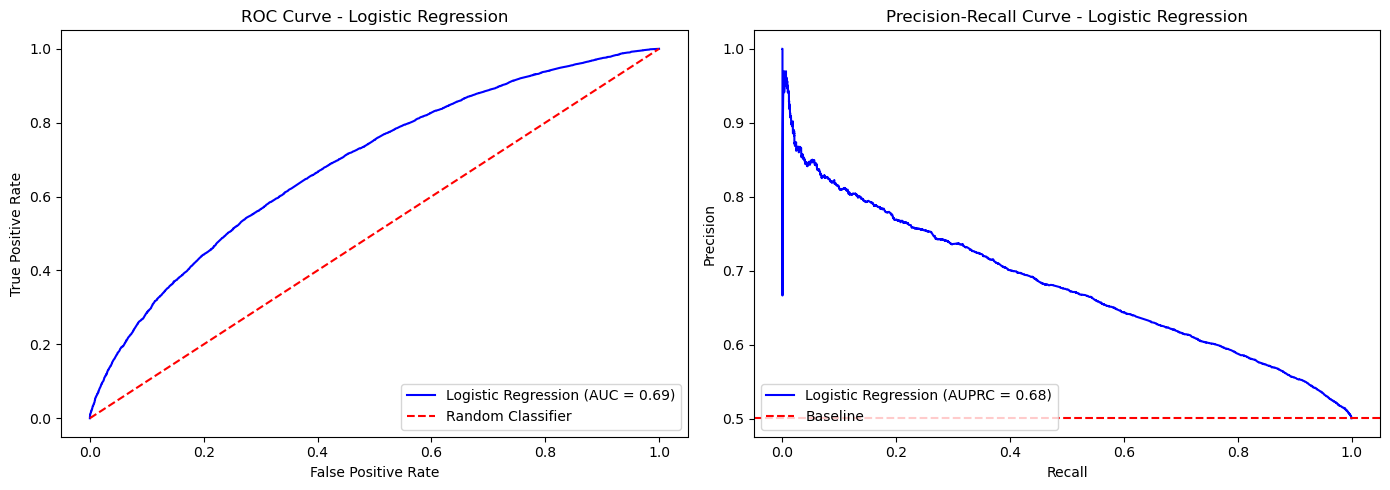

Random Forest - Minority Class Proportion: 0.50


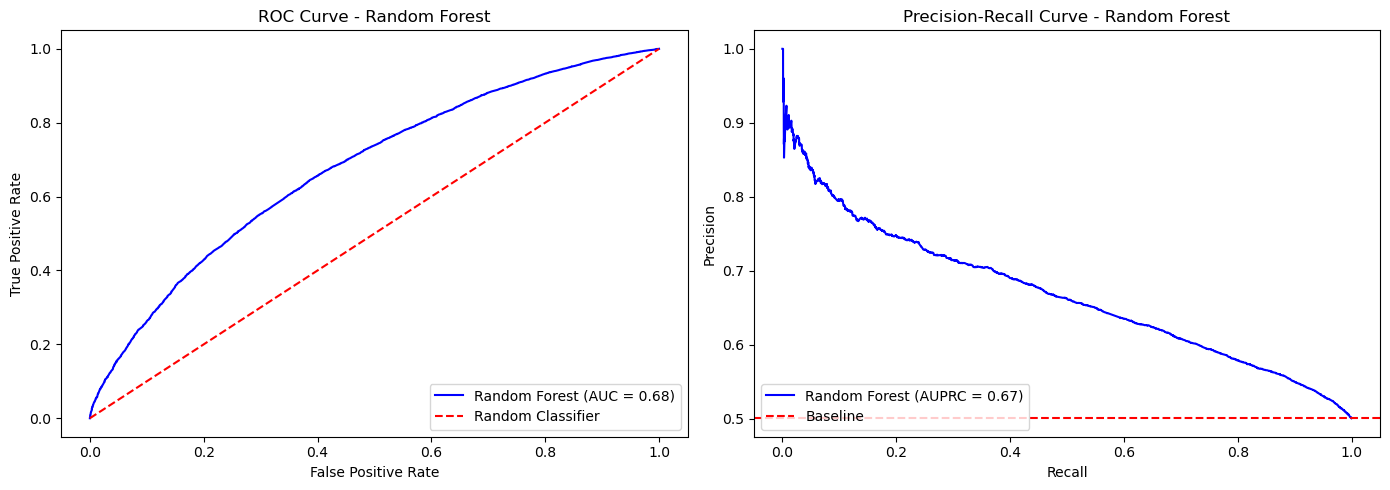

In [8]:
plot_auroc_auprc(y_test, log_model.predict_proba(X_test)[:, 1], "Logistic Regression")
plot_auroc_auprc(y_test, rfc_model.predict_proba(X_test)[:, 1], "Random Forest")

Best kNN Parameters: {'n_neighbors': 9, 'weights': 'uniform'}
kNN Accuracy: 0.59535
kNN Precision: 0.5963716548060539
kNN Recall: 0.5940495207667732
kNN F1 Score: 0.5952083229130195
kNN ROC AUC: 0.6298079373083194
kNN - Minority Class Proportion: 0.50


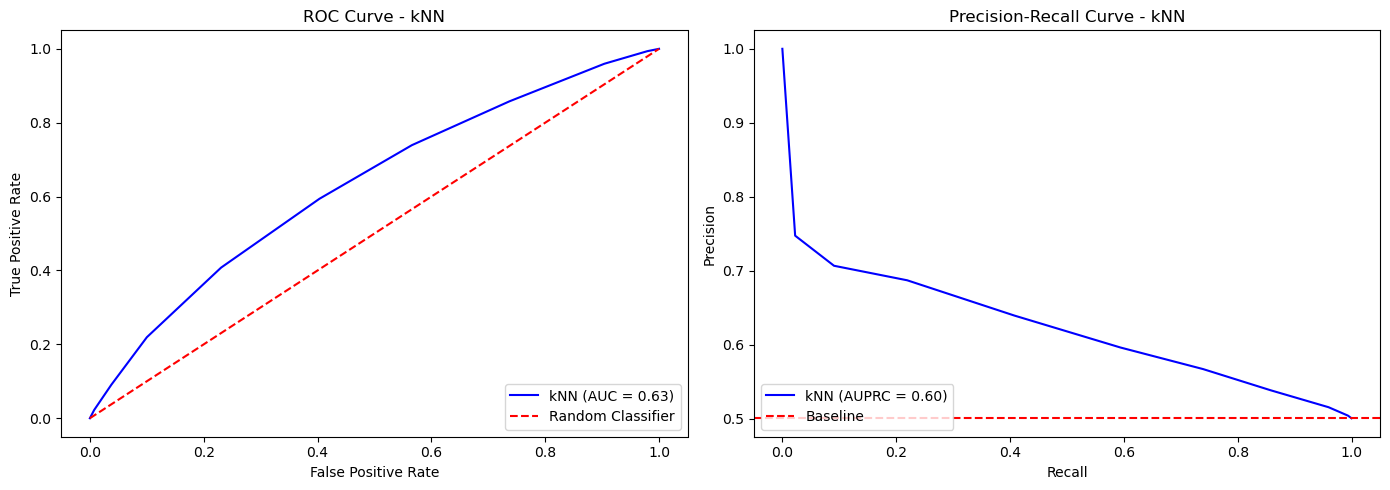

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_params = {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"]}
knn_model = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_model.fit(X_train, y_train)
print("Best kNN Parameters:", knn_model.best_params_)
knn_preds = knn_model.predict(X_test)
print("kNN Accuracy:", accuracy_score(y_test, knn_preds))
print("kNN Precision:", precision_score(y_test, knn_preds))
print("kNN Recall:", recall_score(y_test, knn_preds))
print("kNN F1 Score:", f1_score(y_test, knn_preds))
print("kNN ROC AUC:", roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1]))

plot_auroc_auprc(y_test, knn_model.predict_proba(X_test)[:, 1], "kNN")

In [ ]:
from sklearn.svm import SVC

svm_params = {
            "C": [0.1, 1, 10]
            }
svm_model = GridSearchCV(SVC(), svm_params, cv=5)
svm_model.fit(X_train, y_train)
print("Best SVM Parameters:", svm_model.best_params_)
svm_preds = svm_model.predict(X_test)
print("SVM Recall:", recall_score(y_test, svm_preds))
print("SVM F1 Score:", f1_score(y_test, svm_preds))
print("SVM ROC AUC:", roc_auc_score(y_test, svm_model.predict_proba(X_test)[:, 1]))

plot_auroc_auprc(y_test, svm_model.predict_proba(X_test)[:, 1], "SVM")

In [ ]:
# feature importance RFC
importances = rfc_model.best_estimator_.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Questions for Exploration

1. How do the logistic regression and random forest models compare in terms of accuracy?
2. Which features are the most important in predicting drug sensitivity (IC50)?
3. Are there any features that consistently appear as important across different models? 
4. Are there any surprising or counterintuitive findings in the feature importances? (i.e., would this support or refute any related biological hypothesis?)
5. How robust are the models to changes in the training data? For example, how does the performance change if we use a different random seed for the train-test split?
6. How do the models perform on different subsets of the data (e.g., different cancer subtypes)?
7. What are the optimal hyperparameters for the logistic regression and random forest models?
8. How does the performance change with different hyperparameter settings?